Hai a disposizione un file data.csv contenente dati mensili di traffico aereo con due colonne:

- date: data in formato YYYY-MM (mese/anno)
- passengers: numero di passeggeri per quel mese

Costruisci un modello di regressione polinomiale che approssima l’andamento del numero di passeggeri nel tempo

In [32]:
%conda install numpy
%conda install pandas 
%conda install matplotlib
%conda install scikit-learn
%conda install plotly

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.3.2
    latest 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

1. Carico il dataset

In [3]:
# Importo i dati
df = pd.read_csv('./data/data.csv')
df = df[df['passengers'].notna()]
df.head(5)

,date,passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


2. Convertilo in un formato numerico utilizzando una colonna mese_numerico che conti i mesi a partire da gennaio 1949.

In [4]:
# Creo l'array mese_numerico
mese_numerico = np.arange(0, len(df)) + 1

# Aggiungo la colonna al DataFrame
df['mese_numerico'] = mese_numerico
df.tail()

,date,passengers,mese_numerico
125,1960-07,622.0,126
126,1960-08,606.0,127
127,1960-09,508.0,128
128,1960-10,461.0,129
130,1960-12,432.0,130


3. Applica una regressione polinomiale (grado a tua scelta)

In [29]:
# Definisco la x e la y
X = df[['mese_numerico']]
y = df['passengers'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=False)

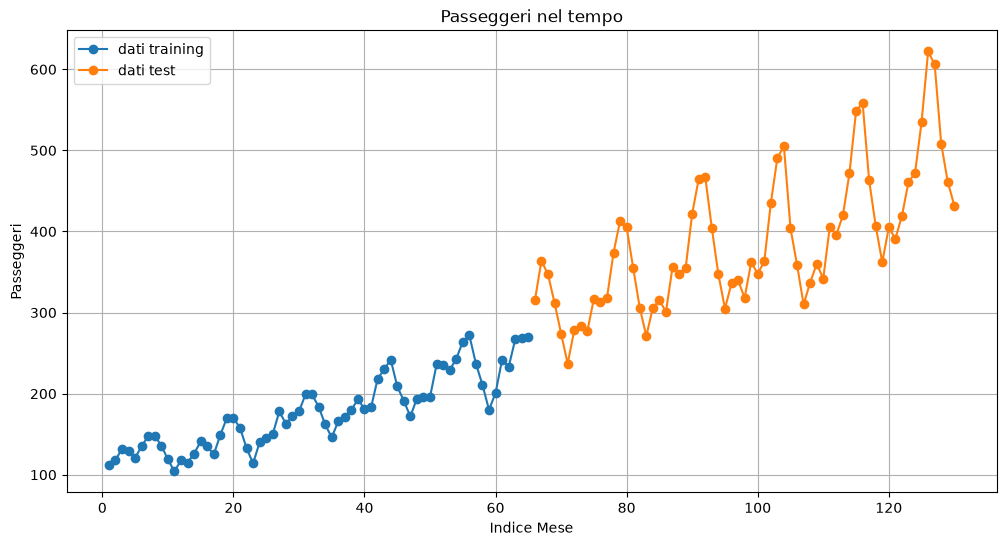

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(X_train, y_train, marker='o', linestyle='-', label='dati training')
plt.plot(X_test, y_test, marker='o', linestyle='-', label='dati test')
plt.title('Passeggeri nel tempo')
plt.xlabel('Indice Mese')
plt.ylabel('Passeggeri')
plt.legend()
plt.grid(True)
plt.show()

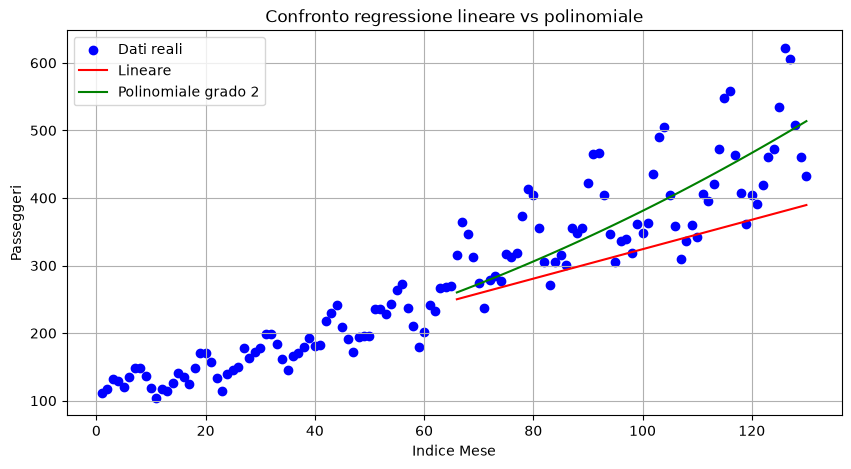

In [31]:
# Regressione lineare
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)

# Regressione polinomiale
model_poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly2.fit(X_train, y_train)
y_pred_poly2 = model_poly2.predict(X_test)

# Disegno il plot
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X_test, y_pred_linear, label=f"Lineare", color="red")
plt.plot(X_test, y_pred_poly2, label=f"Polinomiale grado 2", color="green")
plt.xlabel("Indice Mese")
plt.ylabel("Passeggeri")
plt.title("Confronto regressione lineare vs polinomiale")
plt.legend()
plt.grid(True)
plt.show()

4. Calcola l’RMSE tra i valori reali e quelli predetti.

In [32]:
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)
rmse_poly2 =  root_mean_squared_error(y_test, y_pred_poly2)

print(f"RMSE Lineare: {rmse_linear}")
print(f"RMSE Polinomiale: {rmse_poly2}")

RMSE Lineare: 90.79202164728851
RMSE Polinomiale: 61.72232503452359


5. Visualizza i dati reali e la curva stimata con Plotly

In [35]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=X.values.flatten(),
        y=y,
        name="Dati reali",
        mode="lines+markers",
        line=dict(color="blue", width=4)
    )
)

fig.add_trace(
    go.Scatter(
        x=X_test.values.flatten(),
        y=y_pred_linear,
        name="Regressione lineare",
        mode="lines",
        line=dict(color="green", width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=X_test.values.flatten(),
        y=y_pred_poly2,
        name="Regressione polinomiale",
        mode="lines",
        line=dict(color="red", width=3)
    )
)

fig.update_layout(
    title="Passeggeri nel tempo",
    xaxis_title="Indice mese",
    yaxis_title="Passeggeri"
)

fig.show()